<a href="https://colab.research.google.com/github/kjs444642-alt/diabetes-Prediction-Model/blob/main/11_tf_binding_prediction_RNA_inferience_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeepChem 설치
Colab 노트북에 DeepChem 설치

tensorflow 기반 모델을 사용할 것이므로 pip install 명령에 [tensorflow]를 추가하여 필요한 종속성도 설치

In [ ]:
# DeepChem 설치시 Keras 종속성 버전 일치를 위해 아래 환경 변수 설정 후 import 진행
import os
os.environ["TF_USE_LEGACY_KERAS"] = '1'

In [ ]:
!pip install deepchem[tensorflow]

In [ ]:
!pip install tf_keras

In [ ]:
import deepchem as dc
dc.__version__

'2.5.0'

### warning 메시지 생략

In [ ]:
import warnings
warnings.filterwarnings(action='ignore')

# 전사인자 결합 예측 모델

- JUND 전사 인자의 결합 예측을 위한 CNN 모델 생성
- 2차원 이미지가 아닌 1차원 데이터 사용하는 CNN 모델

### 라이브러리 불러오기

In [ ]:
import deepchem as dc
import tensorflow as tf
import tensorflow.keras.layers as layers

### 데이터 불러오기 및 확인

In [19]:
train = dc.data.DiskDataset('/content/drive/MyDrive/의료데이터분석/drive-download-20260518T010154Z-3-001/train_dataset')
valid = dc.data.DiskDataset('/content/drive/MyDrive/의료데이터분석/drive-download-20260518T010154Z-3-001/valid_dataset')

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
train.X.shape

(276216, 101, 4)

In [21]:
train.y.shape

(276216, 1)

In [22]:
train

<DiskDataset X.shape: (np.int64(276216), np.int64(101), np.int64(4)), y.shape: (np.int64(276216), np.int64(1)), w.shape: (np.int64(276216), np.int64(1)), task_names: [0]>

### 모델 생성

In [23]:
features = tf.keras.Input(shape=(101, 4))
prev = features

for i in range(3):
    prev = layers.Conv1D(filters=15, kernel_size=10, activation=tf.nn.relu, padding='same')(prev)
    prev = layers.Dropout(rate=0.5)(prev)

logits = layers.Dense(units=1)(layers.Flatten()(prev))
output = layers.Activation(tf.math.sigmoid)(logits)

In [24]:
keras_model = tf.keras.Model(inputs=features, outputs=[output, logits])

model = dc.models.KerasModel(
    keras_model,
    loss=dc.models.losses.SigmoidCrossEntropy(),
    output_types=['prediction', 'loss'],
    batch_size=1000,
    model_dir='tf')

### 모델 학습 및 평가

In [25]:
metric = dc.metrics.Metric(dc.metrics.roc_auc_score)
for i in range(20):
    model.fit(train, nb_epoch=10)
    print(model.evaluate(train, [metric]))
    print(model.evaluate(valid, [metric]))

{'roc_auc_score': np.float64(0.6116608580188544)}
{'roc_auc_score': np.float64(0.5714637903301959)}
{'roc_auc_score': np.float64(0.725474421706169)}
{'roc_auc_score': np.float64(0.6652586766424431)}
{'roc_auc_score': np.float64(0.8018563262046317)}
{'roc_auc_score': np.float64(0.7547702757137682)}
{'roc_auc_score': np.float64(0.8168817569775118)}
{'roc_auc_score': np.float64(0.7321827363233835)}
{'roc_auc_score': np.float64(0.8428860069704396)}
{'roc_auc_score': np.float64(0.736593423494101)}
{'roc_auc_score': np.float64(0.8421131149449679)}
{'roc_auc_score': np.float64(0.7327404471966636)}
{'roc_auc_score': np.float64(0.8488799654222247)}
{'roc_auc_score': np.float64(0.7236282145323177)}
{'roc_auc_score': np.float64(0.860866296363514)}
{'roc_auc_score': np.float64(0.7264610451057509)}
{'roc_auc_score': np.float64(0.8604373075740603)}
{'roc_auc_score': np.float64(0.7232444209986959)}
{'roc_auc_score': np.float64(0.8678752403254246)}
{'roc_auc_score': np.float64(0.7334996671066729)}
{'r

# 모델 수정
- Dense층 학습 시 전사 인자 조절에 관여하는 RNA 간섭 feature 추가
- feature 레이어가 2개라 fit함수 사용 불가능
- 배치별 반복 학습 수행
- iterbatches() 함수를 통해 모델에 필요한 입력 데이터 배치별 처리

In [26]:
import numpy as np

In [28]:
span_accessibility = {}
for line in open('/content/drive/MyDrive/의료데이터분석/drive-download-20260518T010154Z-3-001/accessibility.txt'):
    fields = line.split()
    span_accessibility[fields[0]] = float(fields[1])

In [29]:
span_accessibility

{'chr22:20208963-20209064': 0.003902,
 'chr22:29673572-29673673': 0.004378,
 'chr22:28193720-28193821': 0.001946,
 'chr22:43864274-43864375': 0.003869,
 'chr22:18261550-18261651': 0.003066,
 'chr22:49798024-49798125': 0.003794,
 'chr22:43088594-43088695': 0.005292,
 'chr22:35147671-35147772': 0.002015,
 'chr22:49486843-49486944': 0.001046,
 'chr22:21014236-21014337': 0.003394,
 'chr22:46113241-46113342': 0.004074,
 'chr22:18183679-18183780': 0.005725,
 'chr22:50791864-50791965': 0.005023,
 'chr22:18811798-18811899': 0.005777,
 'chr22:36467842-36467943': 0.003452,
 'chr22:33428651-33428752': 0.006423,
 'chr22:50113043-50113144': 0.002428,
 'chr22:33643781-33643882': 0.004774,
 'chr22:33543993-33544094': 0.005169,
 'chr22:50467250-50467351': 0.006465,
 'chr22:37420272-37420373': 0.002894,
 'chr22:50296661-50296762': 0.003144,
 'chr22:19833041-19833142': 0.002302,
 'chr22:33546316-33546417': 0.003757,
 'chr22:24708412-24708513': 0.003336,
 'chr22:46228987-46229088': 0.005614,
 'chr22:3004

In [30]:
features = tf.keras.Input(shape=(101, 4))
accessibility = tf.keras.Input(shape=(1,))

prev = features
for i in range(3):
    prev = layers.Conv1D(filters=15, kernel_size=10, activation=tf.nn.relu, padding='same')(prev)
    prev = layers.Dropout(rate=0.5)(prev)

prev = layers.Concatenate()([layers.Flatten()(prev), accessibility])

logits = layers.Dense(units=1)(prev)
output = layers.Activation(tf.math.sigmoid)(logits)
keras_model = tf.keras.Model(inputs=[features, accessibility], outputs=[output, logits])

model = dc.models.KerasModel(
    keras_model,
    loss=dc.models.losses.SigmoidCrossEntropy(),
    output_types=['prediction', 'loss'],
    batch_size=1000,
    model_dir='chromatin')

In [31]:
def generate_batches(dataset, epochs):
    for epoch in range(epochs):
        for X, y, w, ids in dataset.iterbatches(batch_size=1000, pad_batches=True):
            yield ([X, np.array([span_accessibility[id] for id in ids])], [y], [w])

### 성능 평가

In [32]:
metric = dc.metrics.Metric(dc.metrics.roc_auc_score)
for i in range(20):
    model.fit_generator(generate_batches(train, epochs=10))
    print(model.evaluate_generator(generate_batches(train, 1), [metric]))
    print(model.evaluate_generator(generate_batches(valid, 1), [metric]))

{'roc_auc_score': np.float64(0.6987772397954288)}
{'roc_auc_score': np.float64(0.6815963799099484)}
{'roc_auc_score': np.float64(0.7002650652301498)}
{'roc_auc_score': np.float64(0.6611747961457559)}
{'roc_auc_score': np.float64(0.7623970700739903)}
{'roc_auc_score': np.float64(0.686894480628162)}
{'roc_auc_score': np.float64(0.8158698034094156)}
{'roc_auc_score': np.float64(0.772277665502515)}
{'roc_auc_score': np.float64(0.8586293776311298)}
{'roc_auc_score': np.float64(0.8074122197583593)}
{'roc_auc_score': np.float64(0.8760439492998916)}
{'roc_auc_score': np.float64(0.8157101419743291)}
{'roc_auc_score': np.float64(0.8794564215643769)}
{'roc_auc_score': np.float64(0.821879395892291)}
{'roc_auc_score': np.float64(0.8901813896013039)}
{'roc_auc_score': np.float64(0.8276776166379634)}
{'roc_auc_score': np.float64(0.9007945593595388)}
{'roc_auc_score': np.float64(0.8113086625635249)}
{'roc_auc_score': np.float64(0.8981847692490363)}
{'roc_auc_score': np.float64(0.8322879845479048)}
{'r

# RNA 간섭 예측 모델
- RNA 서열을 입력 데이터로 사용해 RNA 간섭의 효과 예측하는 CNN 모델

In [33]:
import matplotlib.pyplot as plt

### 데이터 불러오기 및 확인

In [34]:
train = dc.data.DiskDataset('/content/drive/MyDrive/의료데이터분석/drive-download-20260518T010154Z-3-001/train_siRNA')
valid = dc.data.DiskDataset('/content/drive/MyDrive/의료데이터분석/drive-download-20260518T010154Z-3-001/valid_siRNA')

In [35]:
train.X.shape

(2187, 21, 4)

In [36]:
train.y.shape

(2187, 1)

In [37]:
train.X

array([[[0, 1, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 0],
        ...,
        [0, 0, 0, 1],
        [0, 1, 0, 0],
        [0, 0, 0, 1]],

       [[0, 1, 0, 0],
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        ...,
        [0, 1, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 0]],

       [[0, 0, 0, 1],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        ...,
        [0, 0, 0, 1],
        [0, 1, 0, 0],
        [0, 0, 0, 1]],

       ...,

       [[1, 0, 0, 0],
        [0, 0, 1, 0],
        [1, 0, 0, 0],
        ...,
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0]],

       [[0, 0, 1, 0],
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        ...,
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [1, 0, 0, 0]],

       [[0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        ...,
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0]]], dtype=int8)

### 모델 생성

In [38]:
features = tf.keras.Input(shape=(21, 4))
prev = features
for i in range(2):
    prev = layers.Conv1D(filters=10, kernel_size=10, activation=tf.nn.relu, padding='same')(prev)
    prev = layers.Dropout(rate=0.3)(prev)
output = layers.Dense(units=1, activation=tf.math.sigmoid)(layers.Flatten()(prev))
keras_model = tf.keras.Model(inputs=features, outputs=output)
model = dc.models.KerasModel(
    keras_model,
    loss=dc.models.losses.L2Loss(),
    batch_size=1000,
    model_dir='rnai')

### 모델 학습 및 평가

In [39]:
train_scores = []
valid_scores = []

In [40]:
metric = dc.metrics.Metric(dc.metrics.pearsonr, mode='regression')

for i in range(20):
    model.fit(train, nb_epoch=10)
    train_score = model.evaluate(train, [metric])['pearsonr']
    valid_score = model.evaluate(valid, [metric])['pearsonr']

    train_scores.append(train_score)
    valid_scores.append(valid_score)

    print(train_score)
    print(valid_score)

0.10093197118386332
0.1240700320726539
0.19997624499325642
0.18819053591371127
0.24503344811277258
0.2183788010468359
0.2718534828653937
0.23908632216793077
0.29361058985526367
0.25617954084666017
0.3105269498632764
0.2738563744620584
0.3211461876167536
0.28512064777873314
0.328785378328338
0.29365675922912743
0.3358078676606663
0.3021062813439126
0.3408608739875016
0.3083638319856773
0.3457659835874139
0.3094075973872457
0.34929504493087105
0.31185061545634174
0.35279356954276553
0.31119929351311504
0.35642255607388934
0.31370749408596404
0.3588553172847142
0.3121597927571015
0.3612181490804579
0.3126992192871072
0.36330367362339044
0.31395473915710015
0.365159959614641
0.31115825387538465
0.367174129680626
0.3130485644689779
0.36848760005396436
0.31356548078419705


### 모델 성능 시각화

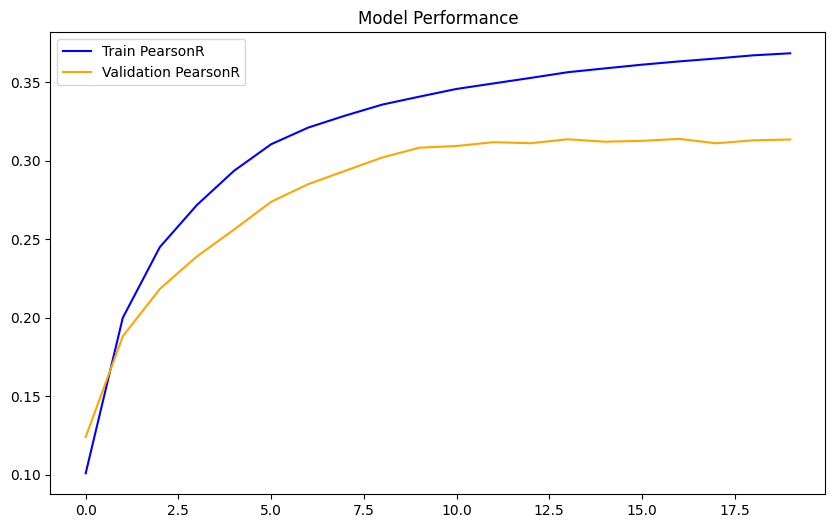

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(train_scores, label='Train PearsonR', color='blue')
plt.plot(valid_scores, label='Validation PearsonR', color='orange')

plt.title('Model Performance')
plt.legend()
plt.show()